# NYU Call Report Data

This notebook provides summary statistics and visualizations for the NYU Call Report data
containing bank-level leverage and liquidity metrics.

## Data Source

Data is publicly available from [NYU Stern](https://pages.stern.nyu.edu/~pschnabl/data/data_callreport.htm).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import chartbook

BASE_DIR = chartbook.env.get_project_root()
DATA_DIR = BASE_DIR / "_data"

warnings.filterwarnings("ignore")

## Load the Datasets

We have four datasets:
1. **Bank Leverage**: Total assets / Total equity at individual bank level
2. **Holding Company Leverage**: Aggregated at bank holding company level
3. **Bank Cash Liquidity**: Cash / Total assets at individual bank level
4. **Holding Company Cash Liquidity**: Aggregated at holding company level

In [2]:
# Load leverage data
leverage_df = pd.read_parquet(DATA_DIR / "ftsfr_nyu_call_report_leverage.parquet")
print(f"Bank Leverage shape: {leverage_df.shape}")
leverage_df.head()

Bank Leverage shape: (1849957, 3)


,unique_id,ds,y
0,1000052,1976-03-31,8.856413
1,1000052,1976-06-30,9.201939
2,1000052,1976-09-30,9.166934
3,1000052,1976-12-31,8.878299
4,1000052,1977-03-31,9.032551


In [3]:
# Load holding company leverage
hc_leverage_df = pd.read_parquet(DATA_DIR / "ftsfr_nyu_call_report_holding_company_leverage.parquet")
print(f"Holding Company Leverage shape: {hc_leverage_df.shape}")
hc_leverage_df.head()

Holding Company Leverage shape: (831858, 3)


,unique_id,ds,y
0,1020199,1976-03-31,14.093732
1,1020199,1976-06-30,14.051833
2,1020199,1976-09-30,14.241946
3,1020199,1976-12-31,13.976336
4,1020199,1977-03-31,14.077098


In [4]:
# Load cash liquidity data
cash_df = pd.read_parquet(DATA_DIR / "ftsfr_nyu_call_report_cash_liquidity.parquet")
print(f"Bank Cash Liquidity shape: {cash_df.shape}")
cash_df.head()

Bank Cash Liquidity shape: (1906765, 3)


,unique_id,ds,y
0,1000052,1976-03-31,0.063697
1,1000052,1976-06-30,0.090671
2,1000052,1976-09-30,0.067859
3,1000052,1976-12-31,0.055985
4,1000052,1977-03-31,0.047882


In [5]:
# Load holding company cash liquidity
hc_cash_df = pd.read_parquet(DATA_DIR / "ftsfr_nyu_call_report_holding_company_cash_liquidity.parquet")
print(f"Holding Company Cash Liquidity shape: {hc_cash_df.shape}")
hc_cash_df.head()

Holding Company Cash Liquidity shape: (832902, 3)


,unique_id,ds,y
0,1020199,1976-03-31,0.076872
1,1020199,1976-06-30,0.075154
2,1020199,1976-09-30,0.076814
3,1020199,1976-12-31,0.087926
4,1020199,1977-03-31,0.074970


## Summary Statistics - Bank Leverage

In [6]:
# Summary statistics for leverage
print("Bank Leverage Summary:")
print(f"  Number of unique banks: {leverage_df['unique_id'].nunique()}")
print(f"  Date range: {leverage_df['ds'].min()} to {leverage_df['ds'].max()}")
print(f"  Observations: {len(leverage_df)}")
print(f"\nLeverage Statistics:")
print(leverage_df['y'].describe())

Bank Leverage Summary:
  Number of unique banks: 22965
  Date range: 1976-03-31 00:00:00 to 2020-03-31 00:00:00
  Observations: 1849957

Leverage Statistics:
count    1.849957e+06
mean     1.186239e+01
std      5.753955e+01
min      9.527121e-01
25%      9.015023e+00
50%      1.112117e+01
75%      1.325725e+01
max      3.652707e+04
Name: y, dtype: float64


## Time Series - Aggregate Leverage

Cross-sectional median leverage over time.

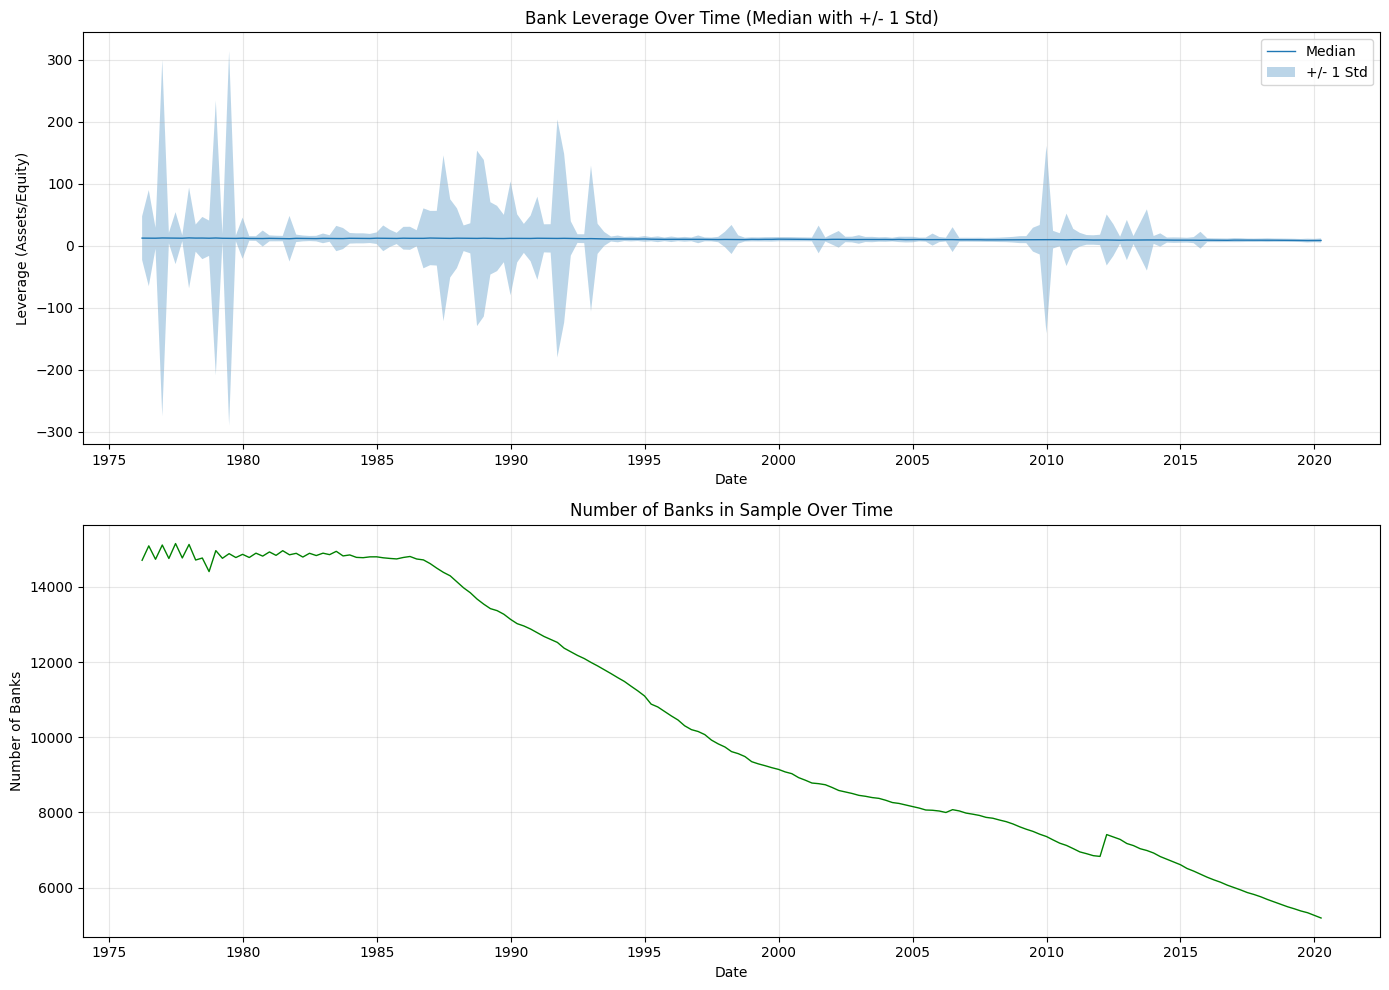

In [7]:
# Calculate aggregate statistics over time
leverage_ts = leverage_df.groupby('ds')['y'].agg(['median', 'mean', 'std', 'count'])
leverage_ts.columns = ['median', 'mean', 'std', 'count']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Median leverage over time
ax = axes[0]
ax.plot(leverage_ts.index, leverage_ts['median'], linewidth=1, label='Median')
ax.fill_between(leverage_ts.index,
                leverage_ts['median'] - leverage_ts['std'],
                leverage_ts['median'] + leverage_ts['std'],
                alpha=0.3, label='+/- 1 Std')
ax.set_title('Bank Leverage Over Time (Median with +/- 1 Std)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Leverage (Assets/Equity)')
ax.legend()
ax.grid(True, alpha=0.3)

# Number of banks over time
ax = axes[1]
ax.plot(leverage_ts.index, leverage_ts['count'], linewidth=1, color='green')
ax.set_title('Number of Banks in Sample Over Time', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Banks')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics - Cash Liquidity

In [8]:
# Summary statistics for cash liquidity
print("Bank Cash Liquidity Summary:")
print(f"  Number of unique banks: {cash_df['unique_id'].nunique()}")
print(f"  Date range: {cash_df['ds'].min()} to {cash_df['ds'].max()}")
print(f"  Observations: {len(cash_df)}")
print(f"\nCash Liquidity Statistics:")
print(cash_df['y'].describe())

Bank Cash Liquidity Summary:
  Number of unique banks: 23862
  Date range: 1976-03-31 00:00:00 to 2020-03-31 00:00:00
  Observations: 1906765

Cash Liquidity Statistics:
count    1.906765e+06
mean     7.975783e-02
std      8.387512e-02
min      0.000000e+00
25%      3.609660e-02
50%      5.780421e-02
75%      9.358769e-02
max      1.023094e+00
Name: y, dtype: float64


## Time Series - Aggregate Cash Liquidity

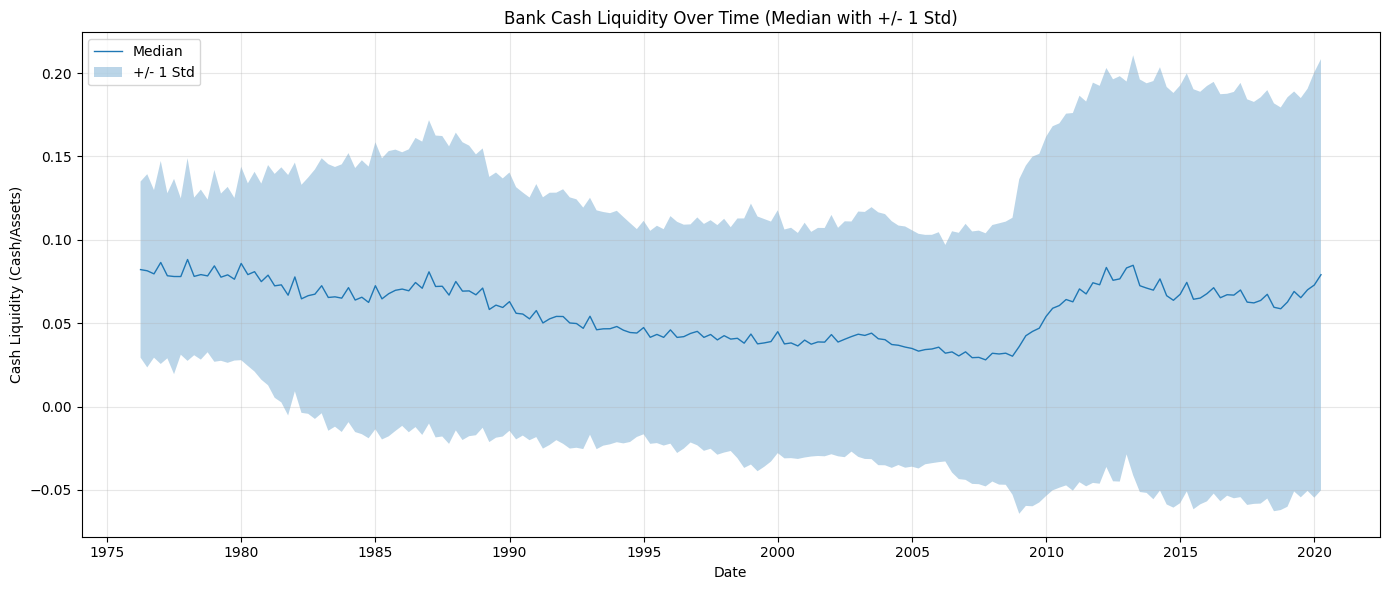

In [9]:
# Calculate aggregate statistics over time
cash_ts = cash_df.groupby('ds')['y'].agg(['median', 'mean', 'std'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cash_ts.index, cash_ts['median'], linewidth=1, label='Median')
ax.fill_between(cash_ts.index,
                cash_ts['median'] - cash_ts['std'],
                cash_ts['median'] + cash_ts['std'],
                alpha=0.3, label='+/- 1 Std')
ax.set_title('Bank Cash Liquidity Over Time (Median with +/- 1 Std)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cash Liquidity (Cash/Assets)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Distribution Analysis

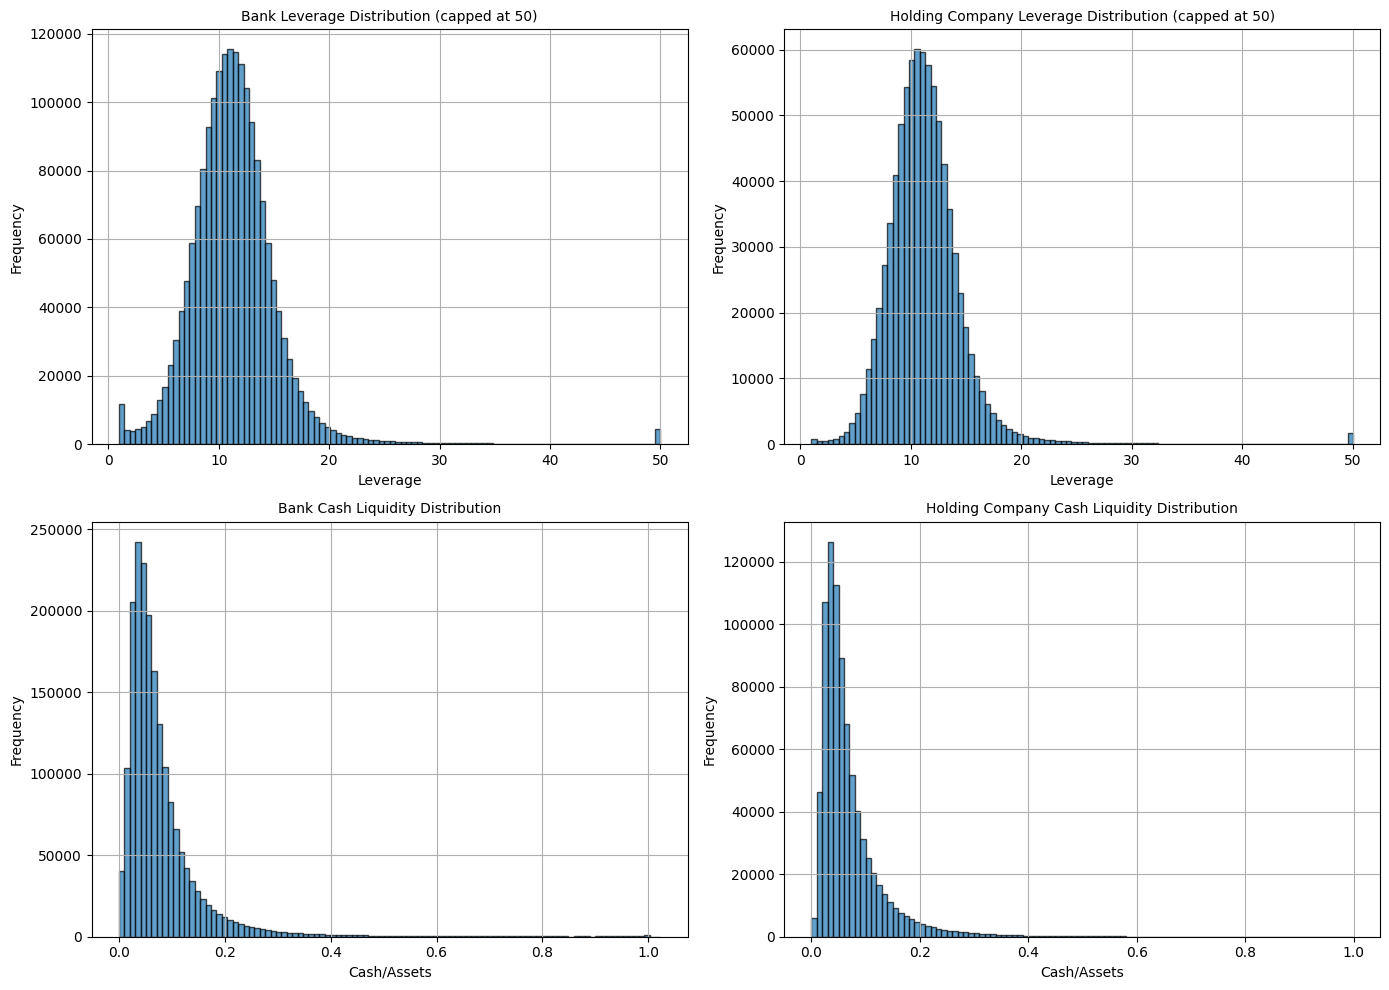

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bank leverage distribution
ax = axes[0, 0]
leverage_df['y'].clip(upper=50).hist(ax=ax, bins=100, edgecolor='black', alpha=0.7)
ax.set_title('Bank Leverage Distribution (capped at 50)', fontsize=10)
ax.set_xlabel('Leverage')
ax.set_ylabel('Frequency')

# Holding company leverage distribution
ax = axes[0, 1]
hc_leverage_df['y'].clip(upper=50).hist(ax=ax, bins=100, edgecolor='black', alpha=0.7)
ax.set_title('Holding Company Leverage Distribution (capped at 50)', fontsize=10)
ax.set_xlabel('Leverage')
ax.set_ylabel('Frequency')

# Bank cash liquidity distribution
ax = axes[1, 0]
cash_df['y'].hist(ax=ax, bins=100, edgecolor='black', alpha=0.7)
ax.set_title('Bank Cash Liquidity Distribution', fontsize=10)
ax.set_xlabel('Cash/Assets')
ax.set_ylabel('Frequency')

# Holding company cash liquidity distribution
ax = axes[1, 1]
hc_cash_df['y'].hist(ax=ax, bins=100, edgecolor='black', alpha=0.7)
ax.set_title('Holding Company Cash Liquidity Distribution', fontsize=10)
ax.set_xlabel('Cash/Assets')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Summary

This dataset provides quarterly bank-level and holding company-level metrics from
regulatory call reports (1976-2020). Key metrics include:

- **Leverage**: Total Assets / Total Equity - measures bank capital structure
- **Cash Liquidity**: Cash / Total Assets - measures liquid asset holdings

These metrics are widely used in:
- Banking regulation and stress testing
- Financial stability monitoring
- Academic research on bank behavior and risk